# Is it just momentum?

The model ranks on trend and momentum features, so the obvious challenge is that it may be an
expensive way to buy something you could get by sorting on one column — or by buying an ETF.

This notebook answers that by comparison rather than by factor regression. Two tests:

1. **Naive 12-1 momentum, run through identical machinery.** Same universe, same top 1% threshold,
   same monthly schedule, same cost model. The *only* thing that changes is the ranking signal:
   `ret_12_1` instead of the random forest. Covers the full 2006-2022 development window.
2. **MTUM**, the iShares momentum ETF — the off-the-shelf alternative you could actually have
   bought. Available from 2013-04, so it is shown over the 2023-2026 holdout where coverage is
   complete.

Test 1 asks *did the model beat simple sorting?* Test 2 asks *could I have just bought it instead?*


In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import sh_analysis as an

DATA, FIGDIR = "data_sharadar", os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)
RF_ANNUAL, RF_DAILY = 0.0375, 0.0375 / 252

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
INK, BLUE, TEAL, AMBER, GREY = "#1f2933", "#2b6cb0", "#0f8b8d", "#d98324", "#9aa5b1"

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True); ax.grid(True, axis="y"); ax.grid(False, axis="x")
    return ax

def save(name, dpi=200):
    p = os.path.join(FIGDIR, f"{name}.png")
    plt.gcf().savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  -> {p}"); plt.show()

def daily_from(df, col):
    s = df[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r

print("ready")

ready


## 1. The model vs naive 12-1 momentum — development, 2006-2022

Both books are built by `sh_book.py` with identical arguments (`--h 40 --adv-floor 25e6 --thr 0.99`,
`monthly_tranche2`, book target 30). The momentum signal was constructed by taking the *exact same
rows* as the model's out-of-sample file — same dates, same eligible universe, same `gpos` — and
replacing the forest's prediction with `ret_12_1`. Nothing else differs.

In [2]:
MODEL = pd.read_parquet(f"{DATA}/sh_books_h40_top1.parquet")
MOM   = pd.read_parquet(f"{DATA}/sh_books_mom121_top1.parquet")
for d in (MODEL, MOM):
    d.index = pd.to_datetime(d.index)

COL = "monthly_tranche2"
dev = pd.DataFrame({
    "model (random forest)": daily_from(MODEL, COL),
    "naive 12-1 momentum":   daily_from(MOM,   COL),
    "SPY":                   daily_from(MODEL, "SPY"),
}).dropna()

tbl = an.metrics_table({c: dev[c] for c in dev.columns}, target=RF_DAILY).set_index("book")
tbl["FinalX"] = [(1 + dev[c]).prod() for c in tbl.index]
print(f"DEV 2006-2022   |   Sharpe / Sortino are EXCESS of Rf = {RF_ANNUAL:.2%}\n")
print(tbl.assign(CAGR=tbl.CAGR.map("{:+.2%}".format), vol=tbl.vol.map("{:.1%}".format),
                 Sharpe=tbl.Sharpe.round(2), Sortino=tbl.Sortino.round(2),
                 maxDD=tbl.maxDD.map("{:.1%}".format), Calmar=tbl.Calmar.round(2),
                 FinalX=tbl.FinalX.map("{:.2f}x".format)).to_string())

DEV 2006-2022   |   Sharpe / Sortino are EXCESS of Rf = 3.75%

                          CAGR    vol  Sharpe  Sortino   maxDD  Calmar  days  FinalX
book                                                                                
model (random forest)  +15.86%  33.6%    0.49     0.71  -62.7%    0.25  4206  11.68x
naive 12-1 momentum     +0.25%  43.1%    0.14     0.19  -76.2%    0.00  4206   1.04x
SPY                     +9.15%  20.1%    0.35     0.49  -55.2%    0.17  4206   4.32x


  -> report/figures/mom_01_dev_vs_naive.png


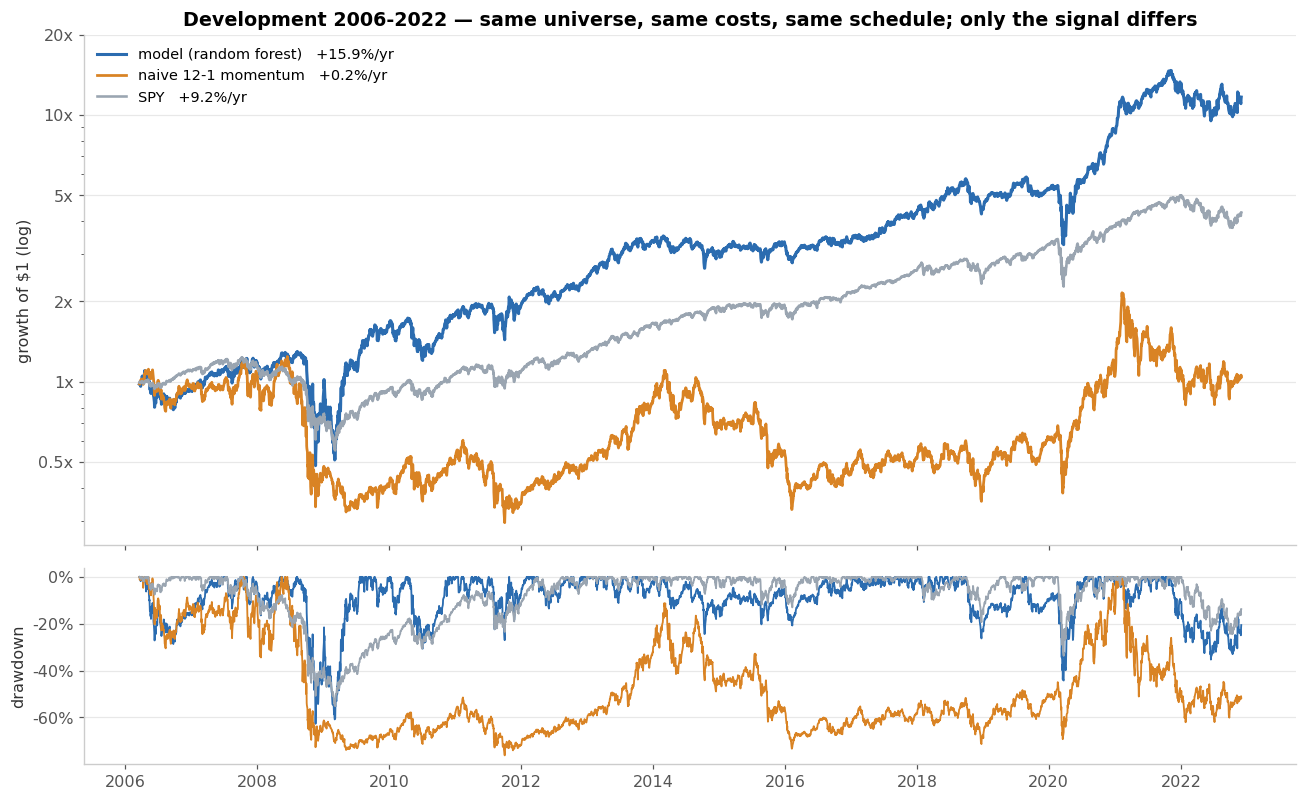

In [3]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.4), sharex=True,
                             gridspec_kw={"height_ratios": [2.6, 1]})
STY = {"model (random forest)": (BLUE, 2.0), "naive 12-1 momentum": (AMBER, 1.8), "SPY": (GREY, 1.7)}
for c, (col, lw) in STY.items():
    eq = (1 + dev[c]).cumprod()
    a1.plot(eq.index, eq.values, color=col, lw=lw, label=f"{c}   {tbl.loc[c,'CAGR']:+.1%}/yr")
    a2.plot(eq.index, (eq / eq.cummax() - 1).values, color=col, lw=1.2)
a1.set_yscale("log")
a1.set_yticks([0.5, 1, 2, 5, 10, 20]); a1.set_yticklabels(["0.5x","1x","2x","5x","10x","20x"])
a1.set_title("Development 2006-2022 — same universe, same costs, same schedule; only the signal differs")
a1.set_ylabel("growth of $1 (log)"); a1.legend(loc="upper left")
a2.set_ylabel("drawdown"); a2.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0%}"))
style(a1); style(a2)
plt.tight_layout(); save("mom_01_dev_vs_naive")

## 2. The model vs MTUM — holdout, 2023-2026

MTUM (iShares MSCI USA Momentum Factor ETF) is the off-the-shelf alternative. It launched
2013-04-18, so it does not cover development; the holdout is where coverage is complete.

⚠️ **This is a practical comparison, not a controlled one.** MTUM holds ~125 large- and mid-cap
names rebalanced semi-annually. The book holds ~20 names rebalanced monthly. The question it answers
is "could I have bought this instead?", not "is my ranking better than momentum?" — test 1 above is
the controlled version.

In [4]:
HOLD = pd.read_parquet(f"{DATA}/sh_books_holdout_h40_top1.parquet")
HOLD.index = pd.to_datetime(HOLD.index)

bm = pd.read_parquet(f"{DATA}/sh_benchmarks.parquet")
mtum = (bm[bm.ticker == "MTUM"].set_index("date")["close"].sort_index())
mtum.index = pd.to_datetime(mtum.index)

hold = pd.DataFrame({
    "model (random forest)": daily_from(HOLD, COL),
    "SPY":                   daily_from(HOLD, "SPY"),
})
hold["MTUM"] = mtum.pct_change(fill_method=None)
hold = hold.dropna()

ht = an.metrics_table({c: hold[c] for c in hold.columns}, target=RF_DAILY).set_index("book")
ht["FinalX"] = [(1 + hold[c]).prod() for c in ht.index]
print(f"HOLDOUT {hold.index.min().date()} .. {hold.index.max().date()}   |   "
      f"Sharpe / Sortino EXCESS of Rf = {RF_ANNUAL:.2%}\n")
print(ht.assign(CAGR=ht.CAGR.map("{:+.2%}".format), vol=ht.vol.map("{:.1%}".format),
                Sharpe=ht.Sharpe.round(2), Sortino=ht.Sortino.round(2),
                maxDD=ht.maxDD.map("{:.1%}".format), Calmar=ht.Calmar.round(2),
                FinalX=ht.FinalX.map("{:.2f}x".format)).to_string())

HOLDOUT 2023-01-05 .. 2026-07-01   |   Sharpe / Sortino EXCESS of Rf = 3.75%

                          CAGR    vol  Sharpe  Sortino   maxDD  Calmar  days FinalX
book                                                                               
model (random forest)  +37.36%  27.4%    1.17     1.70  -26.5%    1.41   874  3.02x
SPY                    +22.57%  15.2%    1.18     1.75  -18.8%    1.20   874  2.03x
MTUM                   +27.98%  20.8%    1.12     1.63  -21.0%    1.33   874  2.36x


HOLDOUT 2023-01-05 .. 2026-07-01  (874 sessions)   |   Sharpe / Sortino EXCESS of Rf = 3.75%

                              CAGR    vol  Sharpe  Sortino   maxDD  Calmar  days FinalX
book                                                                                   
pure long (random forest)  +37.36%  27.4%    1.17     1.70  -26.5%    1.41   874  3.02x
80/20 hedge                +20.90%  17.4%    0.97     1.42  -16.7%    1.25   874  1.94x
SPY                        +22.57%  15.2%    1.18     1.75  -18.8%    1.20   874  2.03x
MTUM                       +27.98%  20.8%    1.12     1.63  -21.0%    1.33   874  2.36x


Exposure — beta and R2 against each yardstick

                           beta vs SPY  R2 vs SPY beta vs MTUM R2 vs MTUM    vol
book                                                                            
pure long (random forest)         1.33       0.54         1.05       0.63  27.4%
80/20 hedge                       0.61       0.29         0.56       0.45  17.4%
MTUM 

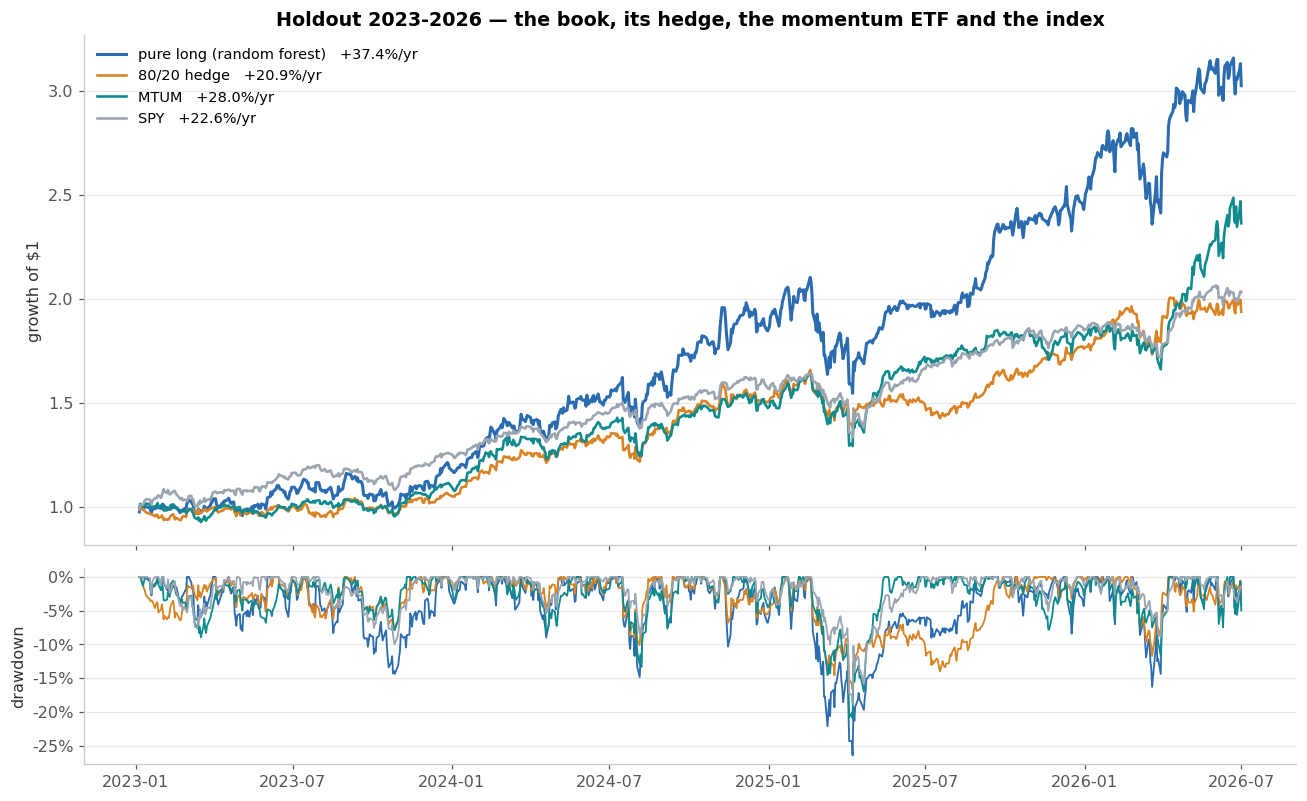

In [5]:
HOLD = pd.read_parquet(f"{DATA}/sh_books_holdout_h40_top1.parquet")
HOLD.index = pd.to_datetime(HOLD.index)

bm = pd.read_parquet(f"{DATA}/sh_benchmarks.parquet")
mtum = (bm[bm.ticker == "MTUM"].set_index("date")["close"].sort_index())
mtum.index = pd.to_datetime(mtum.index)

hold = pd.DataFrame({
    "pure long (random forest)": daily_from(HOLD, COL),
    "80/20 hedge":               daily_from(HOLD, "monthly_tranche2 80/20 hedge"),
    "SPY":                       daily_from(HOLD, "SPY"),
})
hold["MTUM"] = mtum.pct_change(fill_method=None)
hold = hold.dropna()          # every series over identical sessions

ht = an.metrics_table({c: hold[c] for c in hold.columns}, target=RF_DAILY).set_index("book")
ht["FinalX"] = [(1 + hold[c]).prod() for c in ht.index]
print(f"HOLDOUT {hold.index.min().date()} .. {hold.index.max().date()}  ({len(hold)} sessions)   |   "
      f"Sharpe / Sortino EXCESS of Rf = {RF_ANNUAL:.2%}\n")
print(ht.assign(CAGR=ht.CAGR.map("{:+.2%}".format), vol=ht.vol.map("{:.1%}".format),
                Sharpe=ht.Sharpe.round(2), Sortino=ht.Sortino.round(2),
                maxDD=ht.maxDD.map("{:.1%}".format), Calmar=ht.Calmar.round(2),
                FinalX=ht.FinalX.map("{:.2f}x".format)).to_string())

# ── beta of each book against BOTH yardsticks ────────────────────────────────────────────────
def beta_r2(y, x):
    Y, X = hold[y] - RF_DAILY, hold[x] - RF_DAILY
    b = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)
    return b, hold[y].corr(hold[x]) ** 2

print("\n\nExposure — beta and R2 against each yardstick\n")
rows = []
for b in ["pure long (random forest)", "80/20 hedge"]:
    bs, rs = beta_r2(b, "SPY"); bm_, rm = beta_r2(b, "MTUM")
    rows.append({"book": b, "beta vs SPY": round(bs, 2), "R2 vs SPY": round(rs, 2),
                 "beta vs MTUM": round(bm_, 2), "R2 vs MTUM": round(rm, 2),
                 "vol": f"{hold[b].std(ddof=1)*np.sqrt(252):.1%}"})
bs, rs = beta_r2("MTUM", "SPY")
rows.append({"book": "MTUM", "beta vs SPY": round(bs, 2), "R2 vs SPY": round(rs, 2),
             "beta vs MTUM": np.nan, "R2 vs MTUM": np.nan,
             "vol": f"{hold['MTUM'].std(ddof=1)*np.sqrt(252):.1%}"})
print(pd.DataFrame(rows).set_index("book").fillna("—").to_string())

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.4), sharex=True,
                             gridspec_kw={"height_ratios": [2.6, 1]})
STY2 = {"pure long (random forest)": (BLUE, 2.0), "80/20 hedge": (AMBER, 1.7),
        "MTUM": (TEAL, 1.7), "SPY": (GREY, 1.7)}
for c, (col, lw) in STY2.items():
    eq = (1 + hold[c]).cumprod()
    a1.plot(eq.index, eq.values, color=col, lw=lw, label=f"{c}   {ht.loc[c,'CAGR']:+.1%}/yr")
    a2.plot(eq.index, (eq / eq.cummax() - 1).values, color=col, lw=1.2)
a1.set_title("Holdout 2023-2026 — the book, its hedge, the momentum ETF and the index")
a1.set_ylabel("growth of $1"); a1.legend(loc="upper left")
a2.set_ylabel("drawdown"); a2.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0%}"))
style(a1); style(a2)
plt.tight_layout(); save("mom_02_holdout_all")


## 3. The overlap window — 2015 to the end of development

MTUM launched 2013-04, so it cannot cover the whole development period. But from 2015 onward all
three series exist, which gives a like-for-like look at the model, the momentum ETF and the index
over eight years of *development* data — the window the earlier holdout chart could not reach.

⚠️ Two things to keep in mind. This is **in-sample** for the model and out-of-sample for nothing,
so it is a description rather than a test. And it deliberately excludes 2008, which is where a
concentrated momentum book behaves worst.


2015-01-02 .. 2022-12-01   |   Sharpe / Sortino EXCESS of Rf = 3.75%   |   IN-SAMPLE for the model

                          CAGR    vol  Sharpe  Sortino   maxDD  Calmar  days FinalX
book                                                                               
model (random forest)  +18.53%  27.4%    0.62     0.90  -44.2%    0.42  1994  3.84x
naive 12-1 momentum     +5.67%  43.6%    0.26     0.37  -62.0%    0.09  1994  1.55x
SPY                    +11.01%  18.6%    0.45     0.62  -33.7%    0.33  1994  2.29x
MTUM                   +12.01%  20.9%    0.47     0.65  -34.1%    0.35  1994  2.45x
  -> report/figures/mom_03_overlap_2015.png


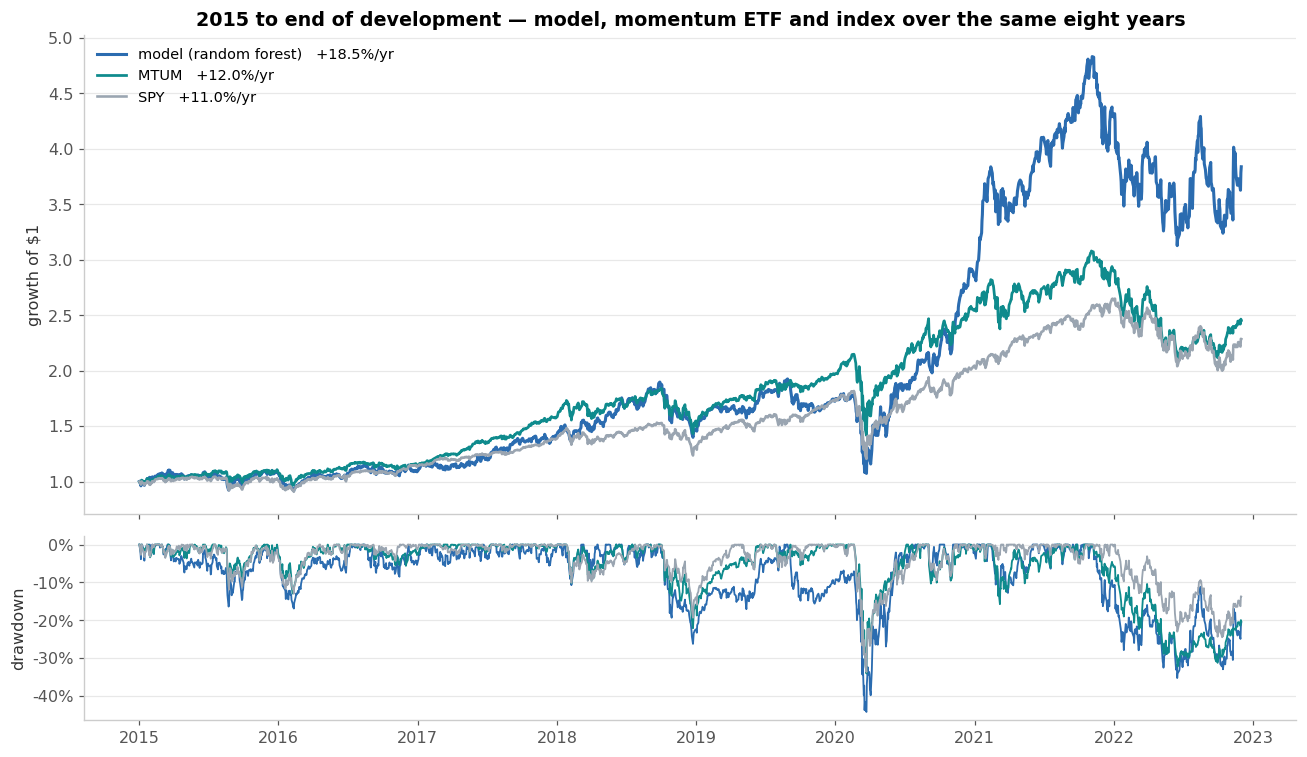

In [6]:
W0, W1 = "2015-01-01", "2022-12-31"

win = pd.DataFrame({
    "model (random forest)": daily_from(MODEL, COL),
    "naive 12-1 momentum":   daily_from(MOM,   COL),
    "SPY":                   daily_from(MODEL, "SPY"),
})
win["MTUM"] = mtum.pct_change(fill_method=None)
win = win.loc[W0:W1].dropna()

wt = an.metrics_table({c: win[c] for c in win.columns}, target=RF_DAILY).set_index("book")
wt["FinalX"] = [(1 + win[c]).prod() for c in wt.index]
print(f"{win.index.min().date()} .. {win.index.max().date()}   |   "
      f"Sharpe / Sortino EXCESS of Rf = {RF_ANNUAL:.2%}   |   IN-SAMPLE for the model\n")
print(wt.assign(CAGR=wt.CAGR.map("{:+.2%}".format), vol=wt.vol.map("{:.1%}".format),
                Sharpe=wt.Sharpe.round(2), Sortino=wt.Sortino.round(2),
                maxDD=wt.maxDD.map("{:.1%}".format), Calmar=wt.Calmar.round(2),
                FinalX=wt.FinalX.map("{:.2f}x".format)).to_string())

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.0), sharex=True,
                             gridspec_kw={"height_ratios": [2.6, 1]})
STY3 = {"model (random forest)": (BLUE, 2.0), "MTUM": (TEAL, 1.8), "SPY": (GREY, 1.7)}
for c, (col, lw) in STY3.items():
    eq = (1 + win[c]).cumprod()
    a1.plot(eq.index, eq.values, color=col, lw=lw, label=f"{c}   {wt.loc[c,'CAGR']:+.1%}/yr")
    a2.plot(eq.index, (eq / eq.cummax() - 1).values, color=col, lw=1.2)
a1.set_title("2015 to end of development — model, momentum ETF and index over the same eight years")
a1.set_ylabel("growth of $1"); a1.legend(loc="upper left")
a2.set_ylabel("drawdown"); a2.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0%}"))
style(a1); style(a2)
plt.tight_layout(); save("mom_03_overlap_2015")


## Verdict

**Against a naive sort, the model wins decisively.** Identical universe, costs, threshold and
schedule; only the ranking signal differs. Sorting on `ret_12_1` alone returned **+0.25%/yr** against
the model's **+15.9%**, with higher volatility (43.1% vs 33.6%) and a deeper drawdown (−76.2% vs
−62.7%). Over seventeen years it turned $1 into $1.04.

The mechanism matters more than the margin. The top 1% by raw 12-month return selects the most
extended names in the universe — small, speculative, already-run — which is why it runs at 43%
volatility. The model sees momentum alongside trend quality, flow, liquidity and market state, and
uses them to avoid the junk end of that distribution. **The value is not in finding momentum; it is
in filtering it.**

**Against a well-built momentum ETF, the picture is more honest.** From 2015 the model beat MTUM on
Sharpe (0.62 vs 0.47), so the development margin is not merely extra risk. But the equity curve shows
the two tracking each other almost exactly from 2015 until late 2020, with essentially all of the
outperformance arriving in the twelve months to November 2021 — the post-COVID melt-up, precisely
the regime a concentrated top-1% book is built for.

**Out of sample the margin disappears.** Over the 2023-2026 holdout the three are tied risk-adjusted:
model 1.17, SPY 1.18, MTUM 1.12. The book earns more in total (3.02x vs 2.36x vs 2.03x) and takes
more risk to do it.

### What this supports

- The machine learning is doing real work: a single-column sort at the same concentration is
  uninvestable.
- The model is *not* simply a momentum proxy, but over 2015-2022 it behaved like one for six of
  eight years.
- Risk-adjusted superiority over an investable momentum alternative is **not** established.

### What it cannot support

Both development windows are in-sample for the model, so they describe rather than test. The holdout
is the only out-of-sample version, it covers 3.6 years of a sustained bull market, and the Monte
Carlo elsewhere in this project shows a window that short cannot separate strategies of this
volatility either way.

MTUM is also not a controlled comparison — ~125 large- and mid-cap names rebalanced semi-annually
against ~20 names rebalanced monthly. It answers "could I have bought this instead?", not "is my
ranking better than momentum?" Test 1 is the controlled version.
